<a href="https://colab.research.google.com/github/gayathribathula/SCT_ML_03/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset already extracted!
Folders: ['cats_set', 'dogs_set']
Number of cat files: 500
Number of dog files: 500

Dataset Shape: (1000, 8100)
Labels Shape: (1000,)
Number of Cats: 500
Number of Dogs: 500

Training samples: 800
Testing samples: 200

Training SVM model...
SVM training completed!

Model Accuracy: 0.76
Accuracy Percentage: 76.00%

Classification Report:

              precision    recall  f1-score   support

         Cat       0.74      0.81      0.77       100
         Dog       0.79      0.71      0.75       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200



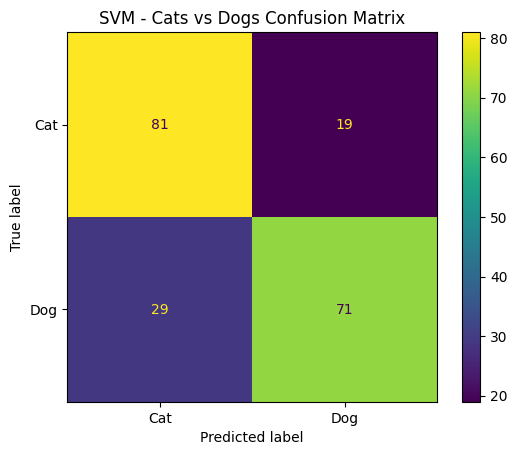

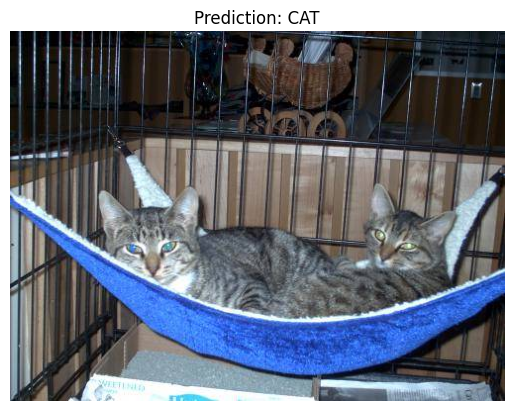

Predicted class: CAT


In [5]:

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

zip_path = "/content/archive (1).zip"
extract_path = "/content/cats_dogs"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted!")

print("Folders:", os.listdir(extract_path))

cat_path = "/content/cats_dogs/cats_set"
dog_path = "/content/cats_dogs/dogs_set"

print("Number of cat files:", len(os.listdir(cat_path)))
print("Number of dog files:", len(os.listdir(dog_path)))


X = []
y = []

def extract_features(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    img = cv2.resize(img, (128, 128))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return features
for file in os.listdir(cat_path):

    image_path = os.path.join(cat_path, file)

    features = extract_features(image_path)

    if features is not None:
        X.append(features)
        y.append(0)

for file in os.listdir(dog_path):

    image_path = os.path.join(dog_path, file)

    features = extract_features(image_path)

    if features is not None:
        X.append(features)
        y.append(1)
X = np.array(X)
y = np.array(y)

print("\nDataset Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Number of Cats:", np.sum(y == 0))
print("Number of Dogs:", np.sum(y == 1))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

print("\nTraining SVM model...")

svm_model.fit(X_train, y_train)

print("SVM training completed!")

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("Accuracy Percentage: {:.2f}%".format(accuracy * 100))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()

plt.title("SVM - Cats vs Dogs Confusion Matrix")
plt.show()


def predict_image(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("Unable to read image.")
        return

    resized = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features = features.reshape(1, -1)

    prediction = svm_model.predict(features)[0]

    if prediction == 0:
        result = "CAT"
    else:
        result = "DOG"

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Prediction: " + result)
    plt.show()

    print("Predicted class:", result)

test_file = os.listdir(cat_path)[0]

test_image_path = os.path.join(cat_path, test_file)

predict_image(test_image_path)